# Copy Correction Procedure

Simplify the copy correction procedure and verify the normalization is properly handled.

**Motivation:** Previous copy correction procedure is incorrect, in that the goal is to make each timepoint equivalent. 

**Procedure:**
1. Normalize all samples by length distribution (and thus equal total number of reads)
2. For each 10k window, determine the replication time and copy number profile (computed from CLOCCS).
3. Reduce the count by half for replicated regions.
4. Question: Should we renormalize the samples? First intuition is, because the entirety of G2/M will now have half the number of reads compared to G1.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 6
span = (20000, 30000)
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)

In [443]:
from src.copy_correction_reanalysis import CopyCorrector
corrector = CopyCorrector(genome_deconvolution)

In [446]:
corrector.perform_correction(1)

111


111


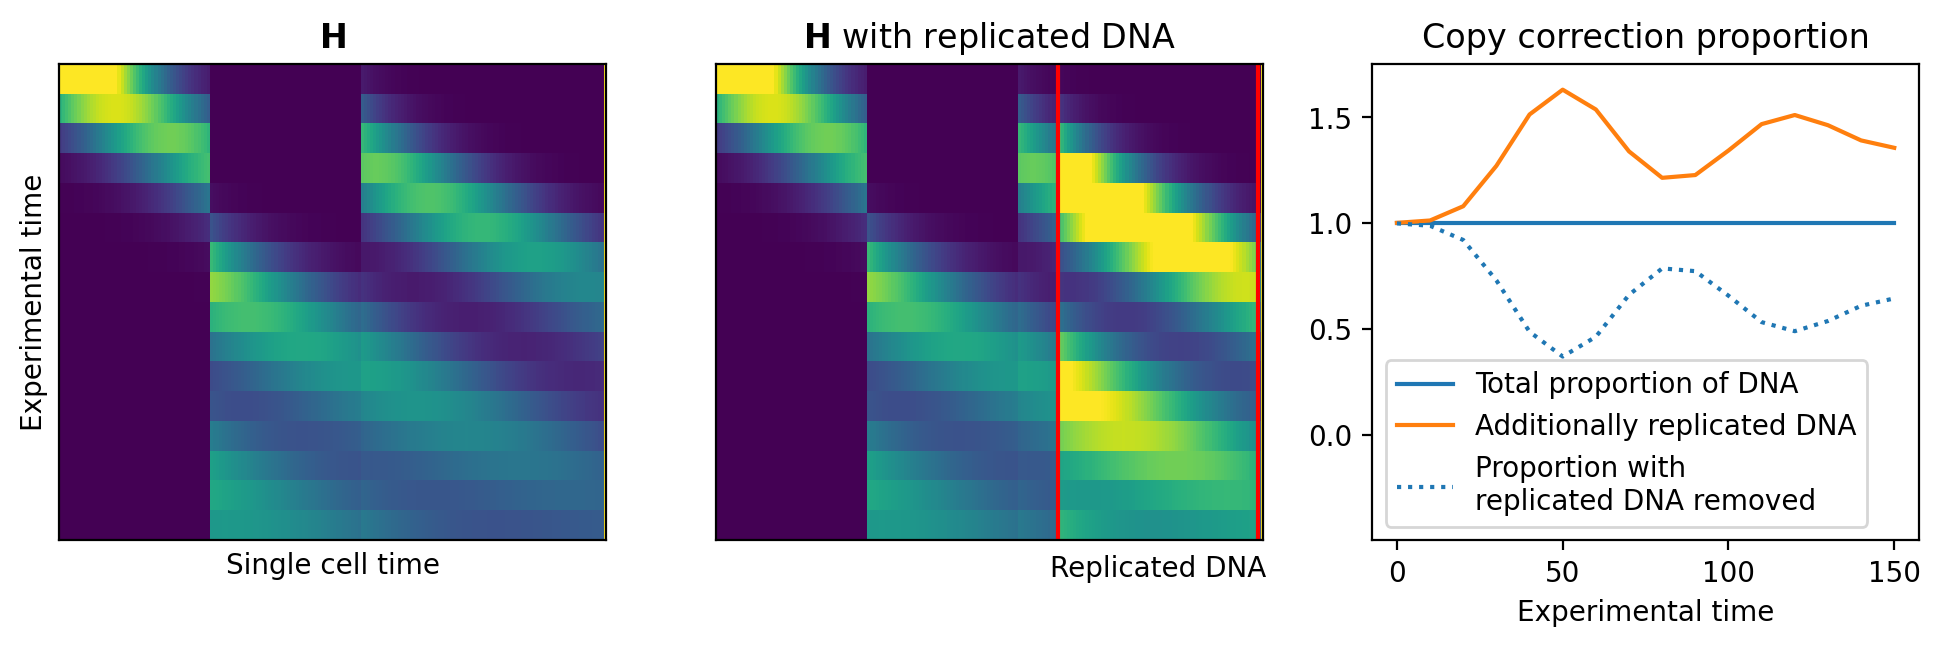

In [447]:
from src.figure_configs import save_figure_for_paper

corrector.plot_correction_H()
save_figure_for_paper('output/figures/Copy_Correction/H_copy_correction.png')

In [96]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
from src.timer import Timer
from src.global_config import GlobalConstants

# Idea: perform copy correction on the normalized 10k windows,
#       following copy correction, the occupancy values will have been reduced
#       and will need to be renormalized such that the total genome has an 
#       equal number of reads for timepoint

all_10k_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')\
    .set_index(['chr', 'start'])

genome_deconvolution = GenomeDeconvolution(save_dir=None)
corrector = CopyCorrector(genome_deconvolution)

timer = Timer()
tps1 = GlobalConstants.CHROM_WT1_TIMEPOINTS
tps2 = GlobalConstants.CHROM_WT2_TIMEPOINTS
    
# Keep track of the uncorrected and corrected 10k window sums
rep1_uncorrected = pd.DataFrame(index=all_10k_windows.index, columns=tps1)
rep1_corrected = pd.DataFrame(index=all_10k_windows.index, columns=tps1)
rep2_uncorrected = pd.DataFrame(index=all_10k_windows.index, columns=tps2)
rep2_corrected = pd.DataFrame(index=all_10k_windows.index, columns=tps2)

for chrom in range(1, 17):
    print(f"Chromosome {chrom}...")

    for start, row in all_10k_windows.loc[chrom].iterrows():

        end = row.end
        span = (start, end)
        genome_deconvolution.load_chrom_span(chrom, span, log=False)
        
        corrector.perform_correction(1)
        rep1_uncorrected.loc[chrom].loc[start] = corrector.uncorrected_reads_sum
        rep1_corrected.loc[chrom].loc[start] = corrector.corrected_reads_sum
        
        corrector.perform_correction(2)
        rep2_uncorrected.loc[chrom].loc[start] = corrector.uncorrected_reads_sum
        rep2_corrected.loc[chrom].loc[start] = corrector.corrected_reads_sum

    print("")
    timer.print_time()


Chromosome 1...
Could not retrieve replication profile for: 1, (230000, 230218)
Applying no correction
Could not retrieve replication profile for: 1, (230000, 230218)
Applying no correction

00:01:56.849
Chromosome 2...
Could not retrieve replication profile for: 2, (810000, 813184)
Applying no correction
Could not retrieve replication profile for: 2, (810000, 813184)
Applying no correction

00:08:43.683
Chromosome 3...
Could not retrieve replication profile for: 3, (310000, 316620)
Applying no correction
Could not retrieve replication profile for: 3, (310000, 316620)
Applying no correction

00:11:14.638
Chromosome 4...
Could not retrieve replication profile for: 4, (1530000, 1531933)
Applying no correction
Could not retrieve replication profile for: 4, (1530000, 1531933)
Applying no correction

00:23:37.148
Chromosome 5...
Could not retrieve replication profile for: 5, (570000, 576874)
Applying no correction
Could not retrieve replication profile for: 5, (570000, 576874)
Applying no c

In [136]:
# Normalize the correction data such that all samples are equal in total read count

def normalize_read_counts(rep1_corrected):
    TOTAL_COUNTS_PER_TIME = 15000000
    rep1_corrected.sum(axis=0).values.reshape((-1, 1))
    rep1_corrected_normalized = rep1_corrected.copy()
    rep1_corrected_normalized.loc[:] = rep1_corrected.values / \
        rep1_corrected.sum(axis=0).values.reshape((1, -1))
    return rep1_corrected_normalized * TOTAL_COUNTS_PER_TIME

rep1_corrected_normalized = normalize_read_counts(rep1_corrected)
rep2_corrected_normalized = normalize_read_counts(rep2_corrected)

In [188]:
rep1_corection_normalization_scalar = (rep1_corrected_normalized+1) / (rep1_uncorrected+1)
rep2_corection_normalization_scalar = (rep2_corrected_normalized+1) / (rep2_uncorrected+1)

In [203]:
rep1_corection_normalization_scalar.to_csv('data/copy_correction/chromatin/copy_correction_replicate1.csv')
rep2_corection_normalization_scalar.to_csv('data/copy_correction/chromatin/copy_correction_replicate2.csv')

In [157]:
sorted_index = corrector.chrom_replication_profile.join(rep1_uncorrected[[]], how='inner')\
    .sort_values('replication_index').index

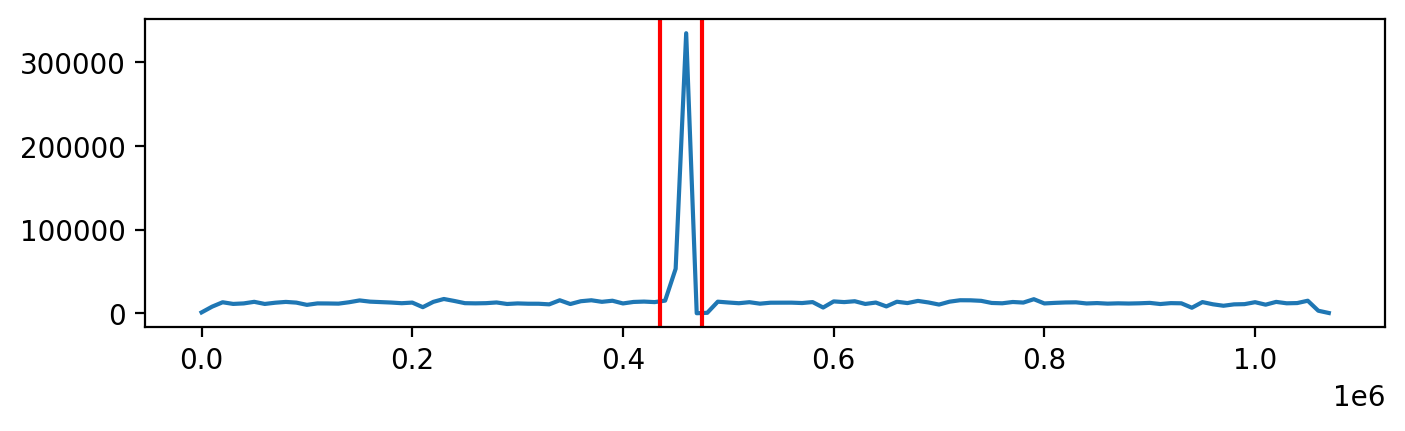

In [289]:
# Remove the repetitive chromosome 12 region

plt.figure(figsize=(8, 2))
plt.plot(rep1_uncorrected.loc[12].mean(axis=1))

mask_span = 435000, 475000
plt.axvline(mask_span[0], c='red')
plt.axvline(mask_span[1], c='red')

removed_chr12_starts_indices = rep1_uncorrected.loc[
    (rep1_uncorrected.index.get_level_values('chr') == 12) & 
    (rep1_uncorrected.index.get_level_values('start') > mask_span[0]) & 
    (rep1_uncorrected.index.get_level_values('start') < mask_span[1])].index

Text(0.5, 1.0, 'Corrected+\nNormalized')

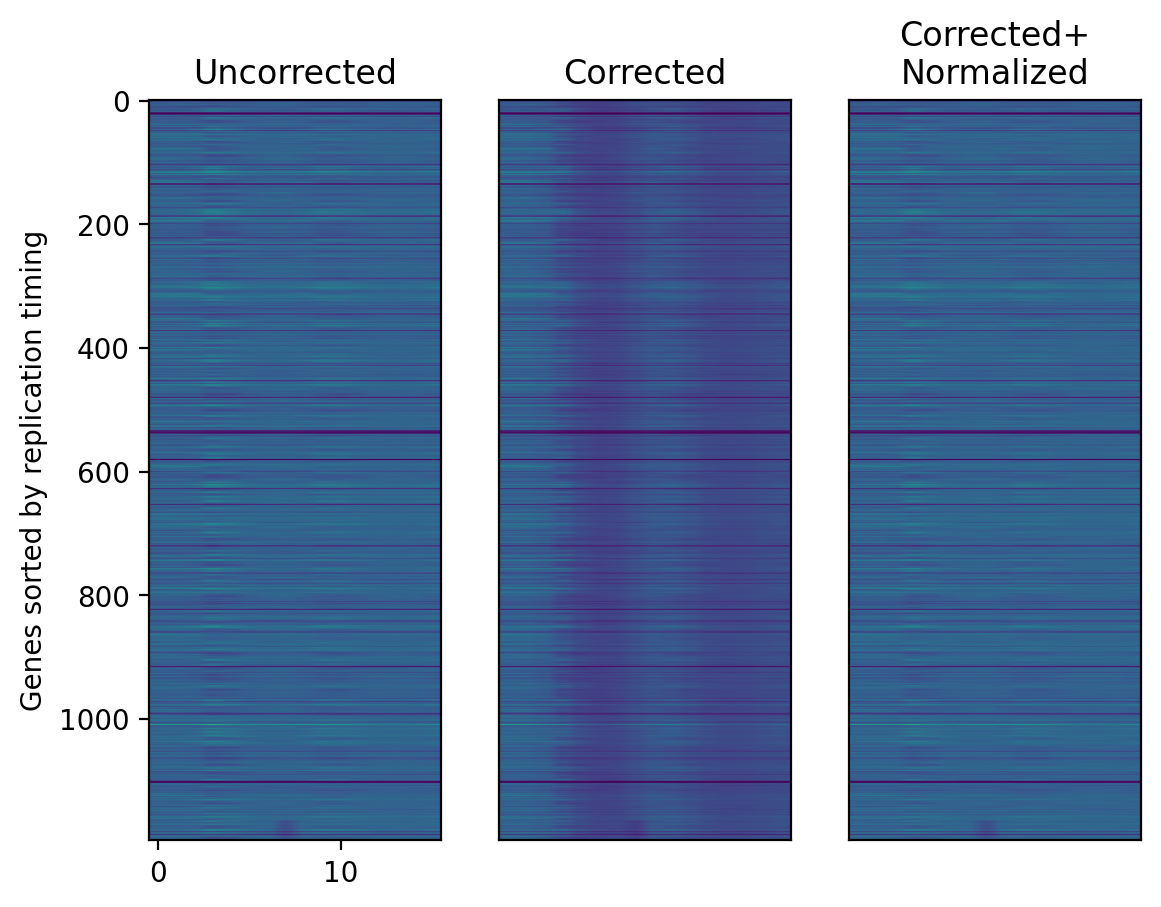

In [280]:
indices_with_masked12 = sorted_index.difference(removed_chr12_starts_indices)

plt.subplot(1, 3, 1)
plt.imshow(rep1_uncorrected.astype(float).loc[indices_with_masked12], 
           aspect='auto', vmin=0, vmax=40000)
plt.title("Uncorrected")
plt.ylabel("Genes sorted by replication timing")

plt.subplot(1, 3, 2)
plt.imshow(rep1_corrected.astype(float).loc[indices_with_masked12],
           aspect='auto', vmin=0, vmax=40000)
plt.yticks([])
plt.xticks([])
plt.title("Corrected")

plt.subplot(1, 3, 3)
plt.imshow(rep1_corrected_normalized.astype(float).loc[indices_with_masked12], 
           aspect='auto', vmin=0, vmax=40000)
plt.yticks([])
plt.xticks([])
plt.title("Corrected+\nNormalized")

In [216]:
from src.peak_to_trough import compute_quantile_ptr_2d

# Let's check the PTR adjustment

rep1_uncorrected_ptr = compute_quantile_ptr_2d(
    rep1_uncorrected, hi=0.9, lo=0.1)
rep1_corrected_normed_ptr = compute_quantile_ptr_2d(
    rep1_corrected_normalized, hi=0.9, lo=0.1)

In [351]:
corrected_ptrs = pd.DataFrame({
    'uncorrected_ptr': rep1_uncorrected_ptr,
    'corrected_ptr': rep1_corrected_ptr,
}, index=rep1_uncorrected.index)

corrected_ptrs = corrected_ptrs.join(corrector.chrom_replication_profile, 
    how='inner')
corrected_ptrs.head()

uncorrected_ptr  corrected_ptr  replication_index  replication_time
chr start                                                                     
1   0             1.213515       1.150054                123          34.99247
    10000         1.092056       1.069555                120          33.35927
    20000         1.166354       1.150893                120          33.35927
    30000         1.087527       1.104088                111          28.45942
    40000         1.096485       1.084716                115          30.63712

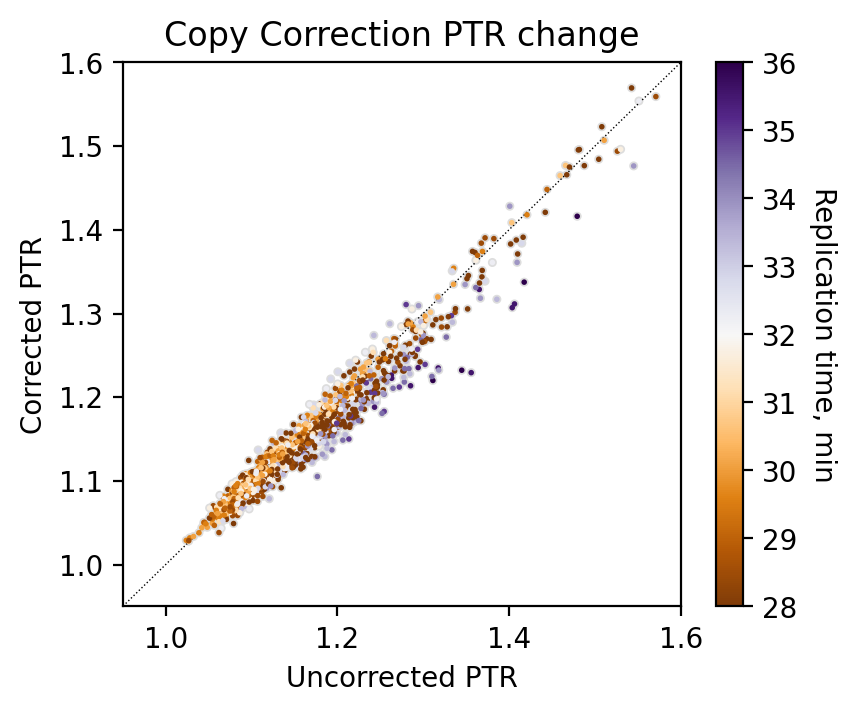

In [467]:


plt.figure(figsize=(4.5, 4))

plt.scatter(corrected_ptrs.uncorrected_ptr, corrected_ptrs.corrected_ptr, 
            s=5,  edgecolor='#dddddd', facecolor='none', zorder=0)

plt.scatter(corrected_ptrs.uncorrected_ptr, corrected_ptrs.corrected_ptr, 
            c=corrected_ptrs.replication_time, s=1, cmap='PuOr',
           vmin=28, vmax=36)
cbar = plt.colorbar()
cbar.ax.set_ylabel("Replication time, min", rotation=270, va='bottom')

plt.plot([0, 5], [0, 5], lw=0.5, ls='dotted', c='black', zorder=0)
plt.xlim(0.95, 1.6)
plt.ylim(0.95, 1.6)
plt.xlabel("Uncorrected PTR")
plt.ylabel("Corrected PTR")
plt.title("Copy Correction PTR change")
plt.subplots_adjust(bottom=0.2)
save_figure_for_paper('output/figures/Copy_Correction/PTR.png')


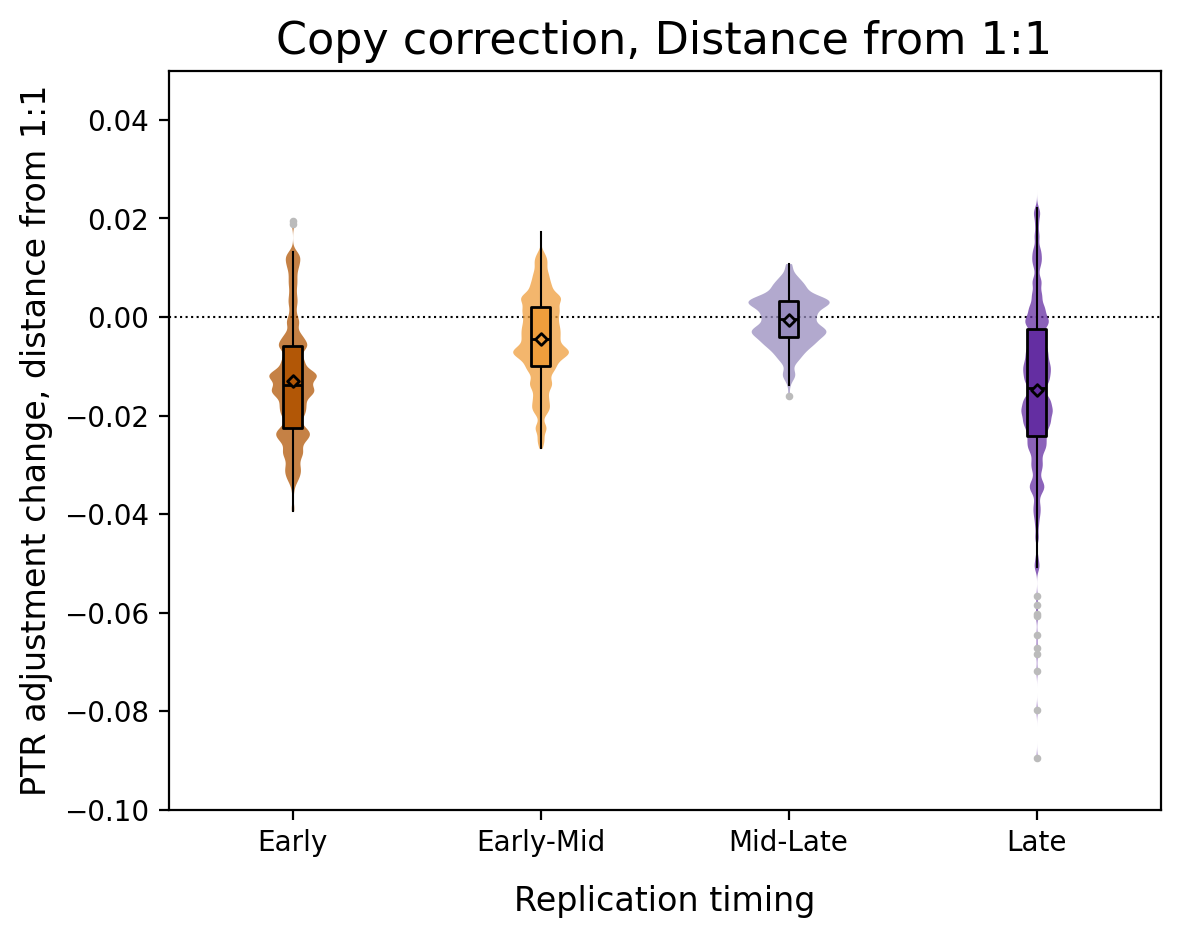

In [464]:
from src.figure_configs import FiguresConfig

# Now look at how the PTR changes per replication timing quantiles

# A refactor of the Figure3_Copy_Correction notebook

def distance_to_line(point, a=1, b=-1, c=0):
    """Compute the distance of a point to a line as defined by: ax + by = c.
    Positive/negative distance correspond to point's relationship to the line. In
    the 1:1 case, positive values indicate x > y and thus below the line.
    """

    x, y = point
    numerator = a*x + b*y + c
    denominator = a**2 + b**2

    distance = numerator / np.sqrt(denominator)

    return distance

# Compute a difference from the 1:1 curve for each gene to designate
# how the copy correction affected the gene's cyclicity as a single value.
ptrs = corrected_ptrs

ptr_values = ptrs[['uncorrected_ptr', 'corrected_ptr']].values
distances = np.apply_along_axis(distance_to_line, axis=1, arr=ptr_values)

# Negative values will associate with, a decrease in PTR following correction
ptr_distances_11 = ptrs[['uncorrected_ptr', 'corrected_ptr']].copy()
ptr_distances_11['distance_11'] = -distances 

# Join with replication profile
ptr_distances_11 = ptr_distances_11.join(corrector.chrom_replication_profile)

# Separate into quantiles of replication timing for violin plotting
# show the change in PTR for each replication timing
from src.helpers import get_quantile_values

ptrs_data_df = data
segments, qvals, lens = get_quantile_values(data.replication_time, 
    q=[0.25, 0.5, 0.75])
    
early_genes, early_mid_genes, mid_late_genes, late_genes = segments

ptrs_data_df.loc[early_genes.index, 'group_id'] = 0
ptrs_data_df.loc[early_mid_genes.index, 'group_id'] = 1
ptrs_data_df.loc[mid_late_genes.index, 'group_id'] = 2
ptrs_data_df.loc[late_genes.index, 'group_id'] = 3

ptrs_data_df.loc[early_genes.index, 'group_name'] = 'Early'
ptrs_data_df.loc[early_mid_genes.index, 'group_name'] = 'Early-Mid'
ptrs_data_df.loc[mid_late_genes.index, 'group_name'] = 'Mid-Late'
ptrs_data_df.loc[late_genes.index, 'group_name'] = 'Late'

# What story does this convey? That early and late replicating regions
# are most influenced by copy number changes...


from src.violinplot import ViolinPlotPlotter

data = ptrs_data_df
violin_plotter = ViolinPlotPlotter()
violin_plotter.set_data([data], data_key='distance_11', group_key='group_id',
                   group_name_key='group_name', category_names=[''])

ax = plt.gca()
title = "Copy correction, Distance from 1:1"

from src.plot_helpers import adjust_lightness_saturation

cmap = plt.get_cmap('PuOr')

violin_plotter.legend = False
violin_plotter.group_colors = [
    adjust_lightness_saturation(cmap(0.1), 1., 1.0),
    cmap(0.25),
    cmap(0.75),
    adjust_lightness_saturation(cmap(0.9), 1.2, 1.0),
]
violin_plotter.plot_box_plot(ax=ax, title='')
ax.set_ylim(-0.1, 0.05)
ax.axhline(0, c='black', lw=0.75, zorder=-1, ls='dotted')
ax.set_ylabel("PTR adjustment change, distance from 1:1", 
              fontsize=FiguresConfig.FIG_LABEL_FONTSIZE)
ax.set_xlabel("Replication timing", fontsize=FiguresConfig.FIG_LABEL_FONTSIZE,
             labelpad=10)
ax.set_title(title, fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
save_figure_for_paper("output/figures/Copy_Correction/PTR_distance_violin.png")


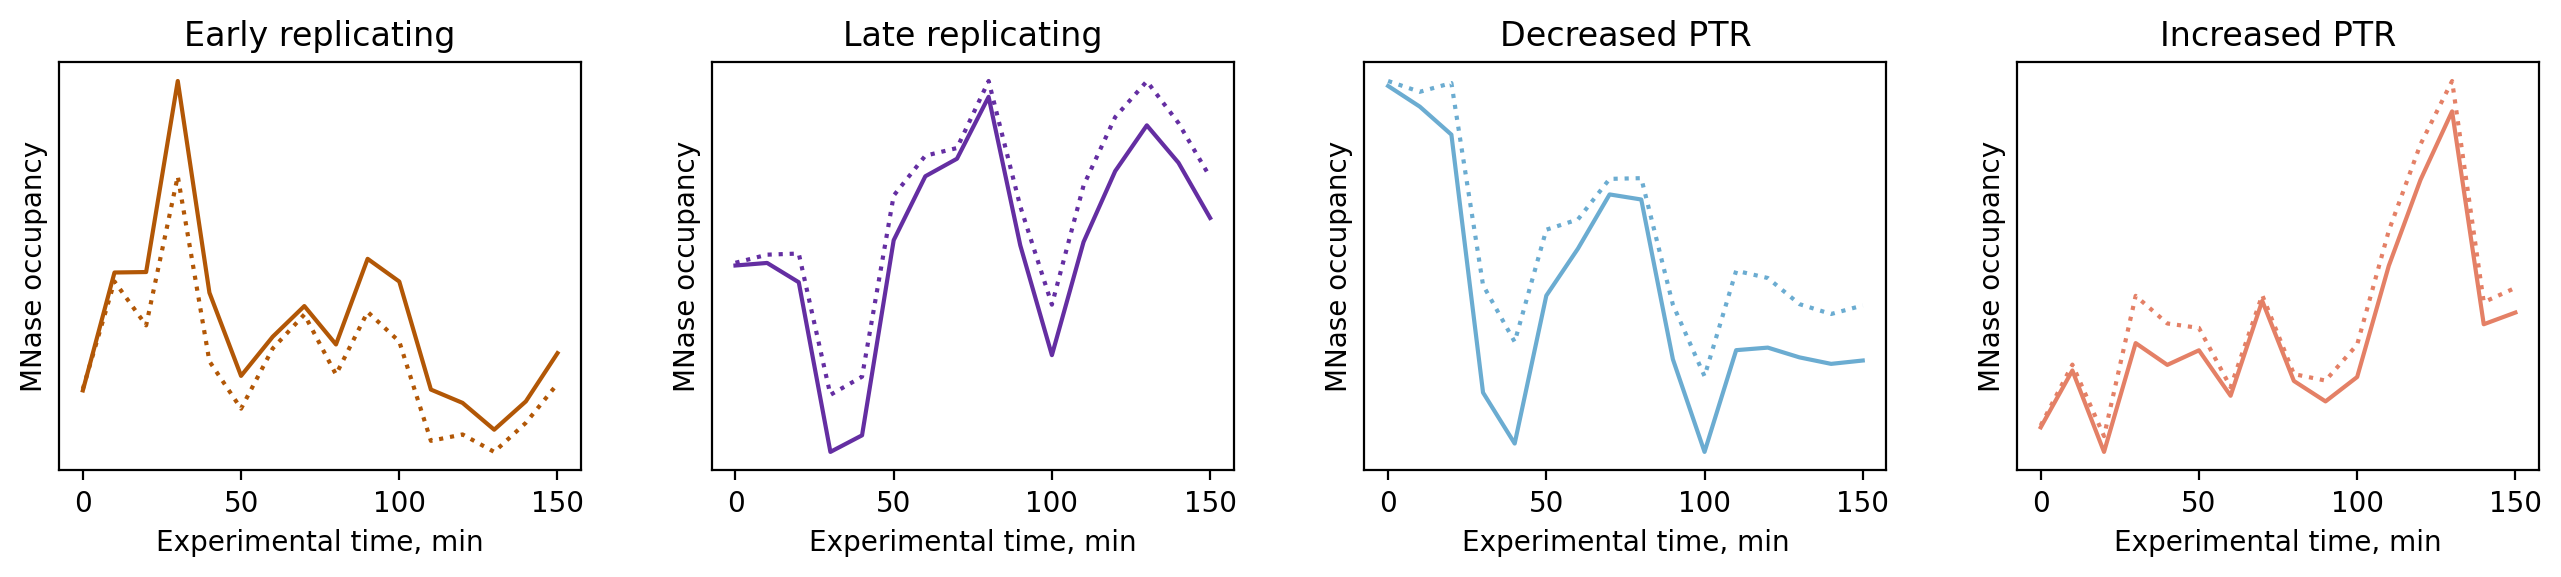

In [466]:
early_color = violin_plotter.group_colors[0]
late_color = violin_plotter.group_colors[-1]

decreased_color = plt.get_cmap('RdBu_r')(0.25)
increased_color = plt.get_cmap('RdBu_r')(0.75)

replication_timing_sorted = ptrs_data_df.sort_values('replication_time')
early_index = replication_timing_sorted.iloc[10].name
late_index = replication_timing_sorted.iloc[-10].name

distance_11_sorted = ptrs_data_df.sort_values('distance_11')
decreased_ptr = distance_11_sorted.iloc[10].name
increased_ptr = distance_11_sorted.iloc[-9].name

plt.figure(figsize=(16, 3))
plt.subplot(1, 4, 1)
plt.plot(rep1_uncorrected.loc[sorted_index].loc[early_index], c=early_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].loc[early_index], c=early_color, 
        ls='dotted')
plt.yticks([])
plt.title("Early replicating")
plt.xlabel("Experimental time, min")
plt.ylabel("MNase occupancy")

plt.subplot(1, 4, 2)
plt.plot(rep1_uncorrected.loc[sorted_index].loc[late_index], c=late_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].loc[late_index], c=late_color,
        ls='dotted')
plt.yticks([])
plt.title("Late replicating")
plt.xlabel("Experimental time, min")
plt.ylabel("MNase occupancy")

plt.subplot(1, 4, 3)
plt.plot(rep1_uncorrected.loc[sorted_index].loc[decreased_ptr], c=decreased_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].loc[decreased_ptr], c=decreased_color,
        ls='dotted')
plt.yticks([])
plt.title("Decreased PTR")
plt.xlabel("Experimental time, min")
plt.ylabel("MNase occupancy")

plt.subplot(1, 4, 4)
plt.plot(rep1_uncorrected.loc[sorted_index].loc[increased_ptr], c=increased_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].loc[increased_ptr], c=increased_color, 
        ls='dotted')
plt.yticks([])
plt.title("Increased PTR")
plt.xlabel("Experimental time, min")
plt.ylabel("MNase occupancy")
plt.subplots_adjust(hspace=0.6, wspace=0.25, bottom=0.2)

save_figure_for_paper('output/figures/Copy_Correction/Examples_correction_curves.png')
